# DEEPL LEARNING WITH LSTM & BiLSTM

In [ ]:
!pip install tensorflow scikit-learn pandas matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Embedding,LSTM,Bidirectional,Dropout)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
df = pd.read_csv("cleaned_data.csv")
df.head()

,Unnamed: 0,Date Created,Number of Likes,Source of Tweet,Tweet,Sentiment,clean_text
0,0,2022-11-20 23:59:21+00:00,4,Twitter Web App,What are we drinking today @TucanTribe \n@MadB...,neutral,drinking today worldcup
1,1,2022-11-20 23:59:01+00:00,3,Twitter for iPhone,Amazing @CanadaSoccerEN #WorldCup2022 launch ...,positive,amazing worldcup launch video show much face c...
2,2,2022-11-20 23:58:41+00:00,1,Twitter for iPhone,Worth reading while watching #WorldCup2022 htt...,positive,worth reading watching worldcup
3,3,2022-11-20 23:58:33+00:00,1,Twitter Web App,Golden Maknae shinning bright\n\nhttps://t.co/...,positive,golden maknae shinning bright jeonjungkook jun...
4,4,2022-11-20 23:58:28+00:00,0,Twitter for Android,"If the BBC cares so much about human rights, h...",negative,bbc care much human right homosexual right wom...


In [ ]:
print(df.columns)
print(df["Sentiment"].value_counts())

Index(['Unnamed: 0', 'Date Created', 'Number of Likes', 'Source of Tweet',
       'Tweet', 'Sentiment', 'clean_text'],
      dtype='object')
Sentiment
positive    8489
neutral     8251
negative    5784
Name: count, dtype: int64


In [ ]:
texts = df["clean_text"].astype(str)
labels = df["Sentiment"]

In [ ]:
label_encoder = LabelEncoder()

labels_encoded = label_encoder.fit_transform(labels)

y = to_categorical(labels_encoded)

print(label_encoder.classes_)

['negative' 'neutral' 'positive']


In [ ]:
MAX_WORDS = 10000
MAX_LEN = 100

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token="<OOV>"
)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

X = pad_sequences(
    sequences,
    maxlen=MAX_LEN,
    padding='post'
)
print(X.shape)

(22524, 100)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=labels_encoded
)
print(X_train.shape)

(18019, 100)


In [ ]:
lstm_model = Sequential()
lstm_model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_shape=(MAX_LEN,)
    )
)
lstm_model.add(
    LSTM(
        128,
        return_sequences=False
    )
)
lstm_model.add(
    Dropout(0.5)
)
lstm_model.add(
    Dense(
        64,
        activation='relu'
    )
)
lstm_model.add(
    Dense(
        3,
        activation='softmax'
    )
)
lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,035 (5.42 MB)

 Trainable params: 1,420,035 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_lstm = lstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2)

Epoch 1/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 49s 210ms/step - accuracy: 0.3750 - loss: 1.0874 - val_accuracy: 0.3588 - val_loss: 1.0858
Epoch 2/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 73s 171ms/step - accuracy: 0.3716 - loss: 1.0878 - val_accuracy: 0.3948 - val_loss: 1.0814
Epoch 3/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 37s 164ms/step - accuracy: 0.3700 - loss: 1.0867 - val_accuracy: 0.3948 - val_loss: 1.0826
Epoch 4/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 37s 165ms/step - accuracy: 0.3779 - loss: 1.0861 - val_accuracy: 0.3948 - val_loss: 1.0867
Epoch 5/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 38s 166ms/step - accuracy: 0.3749 - loss: 1.0865 - val_accuracy: 0.3588 - val_loss: 1.0818
Epoch 6/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 40s 177ms/step - accuracy: 0.3668 - loss: 1.0864 - val_accuracy: 0.3588 - val_loss: 1.0823
Epoch 7/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 38s 164ms/step - accuracy: 0.3687 - loss: 1.0863 - val_accuracy: 0.3588 - val_loss: 1.0836
Epoch 8/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 37s 165ms/step - accuracy: 0.3664 - loss: 1

In [ ]:
lstm_predictions = lstm_model.predict(X_test)
lstm_predictions = np.argmax(
    lstm_predictions,
    axis=1)
y_true = np.argmax(y_test, axis=1)
print(
    classification_report(
        y_true,
        lstm_predictions,
        target_names=label_encoder.classes_))
lstm_accuracy = accuracy_score(
    y_true,
    lstm_predictions)
print("LSTM Accuracy:", lstm_accuracy)

141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00      1157
     neutral       0.00      0.00      0.00      1650
    positive       0.38      1.00      0.55      1698

    accuracy                           0.38      4505
   macro avg       0.13      0.33      0.18      4505
weighted avg       0.14      0.38      0.21      4505

LSTM Accuracy: 0.37691453940066594


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


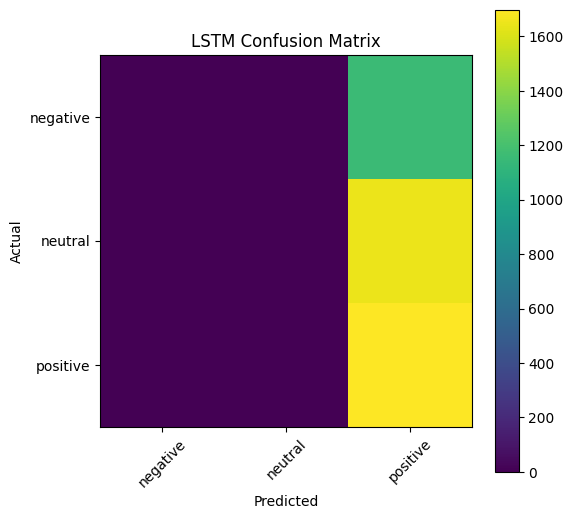

In [ ]:
cm = confusion_matrix(
    y_true,
    lstm_predictions
)
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("LSTM Confusion Matrix")
plt.colorbar()
plt.xticks(
    range(3),
    label_encoder.classes_,
    rotation=45)
plt.yticks(
    range(3),
    label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
bilstm_model = Sequential()
bilstm_model.add(
    Embedding(
        input_dim=MAX_WORDS,
        output_dim=128,
        input_shape=(MAX_LEN,)))
bilstm_model.add(
    Bidirectional(
        LSTM(
            128,
            return_sequences=False)))
bilstm_model.add(
    Dropout(0.5))
bilstm_model.add(
    Dense(
        64,
        activation='relu'))
bilstm_model.add(
    Dense(
        3,
        activation='softmax'))
bilstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])
bilstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,559,811 (5.95 MB)

 Trainable params: 1,559,811 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_bilstm = bilstm_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,)

Epoch 1/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 70s 309ms/step - accuracy: 0.8354 - loss: 0.4071 - val_accuracy: 0.7234 - val_loss: 0.7175
Epoch 2/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 81s 306ms/step - accuracy: 0.8672 - loss: 0.3352 - val_accuracy: 0.7206 - val_loss: 0.7956
Epoch 3/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 69s 305ms/step - accuracy: 0.8903 - loss: 0.2788 - val_accuracy: 0.7156 - val_loss: 0.8141
Epoch 4/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 82s 307ms/step - accuracy: 0.9055 - loss: 0.2364 - val_accuracy: 0.7128 - val_loss: 0.8829
Epoch 5/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 69s 307ms/step - accuracy: 0.9181 - loss: 0.2047 - val_accuracy: 0.7098 - val_loss: 1.0493
Epoch 6/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 69s 307ms/step - accuracy: 0.9283 - loss: 0.1811 - val_accuracy: 0.7062 - val_loss: 1.0906
Epoch 7/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - accuracy: 0.9328 - loss: 0.1684 - val_accuracy: 0.7056 - val_loss: 1.2213
Epoch 8/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 69s 306ms/step - accuracy: 0.9393 - loss: 0

In [ ]:
bilstm_predictions = bilstm_model.predict(X_test)
bilstm_predictions = np.argmax(
    bilstm_predictions,
    axis=1)
print(
    classification_report(
        y_true,
        bilstm_predictions,
        target_names=label_encoder.classes_))
bilstm_accuracy = accuracy_score(
    y_true,
    bilstm_predictions)
print("BiLSTM Accuracy:", bilstm_accuracy)

141/141 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step
              precision    recall  f1-score   support

    negative       0.66      0.66      0.66      1157
     neutral       0.63      0.64      0.63      1650
    positive       0.72      0.71      0.71      1698

    accuracy                           0.67      4505
   macro avg       0.67      0.67      0.67      4505
weighted avg       0.67      0.67      0.67      4505

BiLSTM Accuracy: 0.6708102108768036


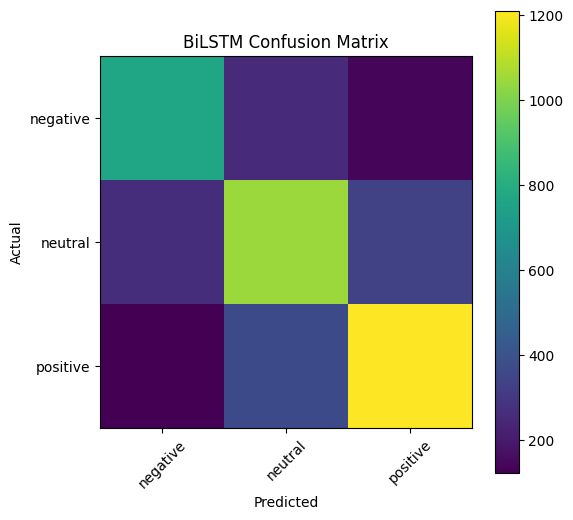

In [ ]:
cm = confusion_matrix(
    y_true,
    bilstm_predictions)
plt.figure(figsize=(6,6))
plt.imshow(cm)
plt.title("BiLSTM Confusion Matrix")
plt.colorbar()
plt.xticks(
    range(3),
    label_encoder.classes_,
    rotation=45)
plt.yticks(
    range(3),
    label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

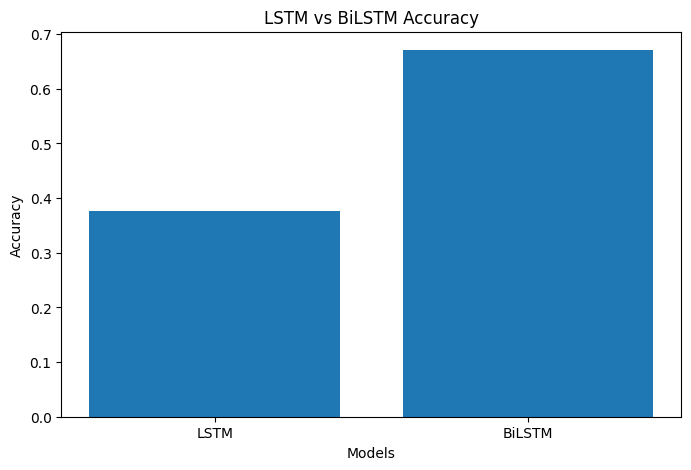

In [ ]:
models = [
    "LSTM",
    "BiLSTM"]
accuracies = [
    lstm_accuracy,
    bilstm_accuracy]
plt.figure(figsize=(8,5))
plt.bar(
    models,
    accuracies)
plt.title("LSTM vs BiLSTM Accuracy")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
lstm_model.save("lstm_model.h5")
bilstm_model.save("bilstm_model.h5")
print("Models Saved Successfully")

Models Saved Successfully
